In [39]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sb

In [40]:
plt.style.use('fivethirtyeight')
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline

In [41]:
train_data = pd.read_csv('train.csv')

In [42]:
#To see where Jupyter is currently looking for files, run this in a code cell
import os
print(os.getcwd())

C:\Users\acer\Downloads\python project


In [43]:
train_data.shape #to check the dimension(size of the data)

(891, 12)

In [44]:
train_data.head(10) #it displays the first 10 rows of your DataFrame.

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,NaN,S
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,NaN,C


In [45]:
test_data = pd.read_csv('test.csv')

In [46]:
test_data.head() #displays the first 5 rows of your test_data DataFrame.

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


In [47]:
#isnull is basically used to detect missing and null value.
train_data.isnull().sum() #counts and displays the total number of missing (NaN) values in each column of your dataset.

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

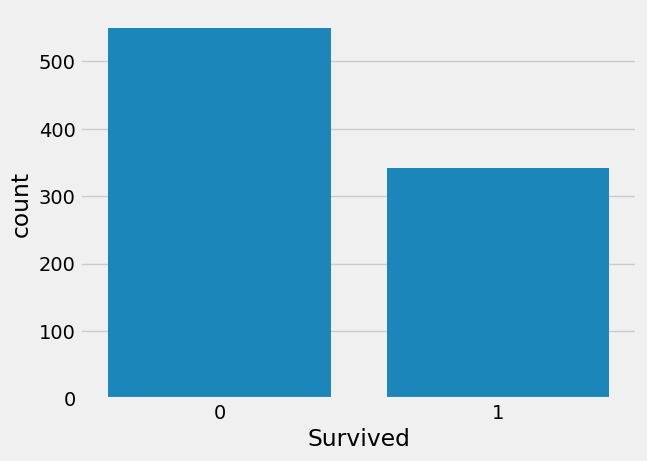

In [48]:
#creates a bar chart showing the frequency (count) of each category in the Survived column.
sb.countplot(x='Survived', data=train_data)
plt.show()

In [49]:
#shows the breakdown of how many males and females survived vs. died in your dataset.
train_data.groupby(['Sex', 'Survived'])['Survived'].count()

Sex     Survived
female  0            81
        1           233
male    0           468
        1           109
Name: Survived, dtype: int64

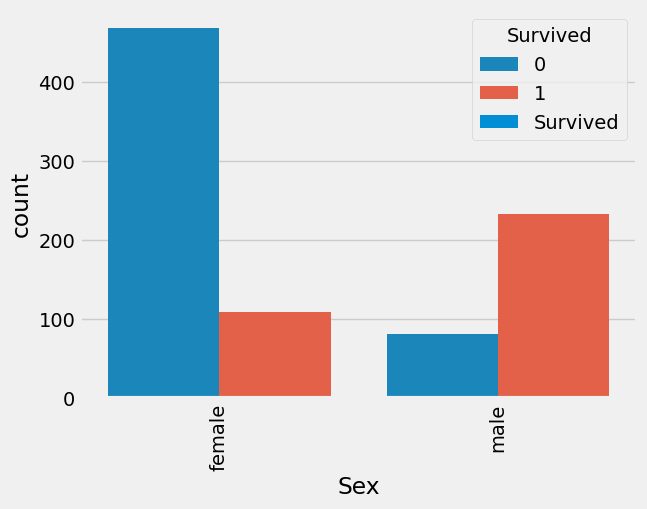

In [50]:
#shows the total count of male and female passengers split by whether they survived or died.
#x-axis (Sex): Separates passengers into female and male.
#y-axis (count): Shows the exact number of passengers.
#Colors (hue='Survived'):
#Blue Bar (0): Passengers who died.
#Orange Bar (1): Passengers who survived.

train_data[['Sex', 'Survived']].groupby(['Sex']).mean().plot.bar()
sb.countplot(x='Sex', hue='Survived', data=train_data)
plt.show()

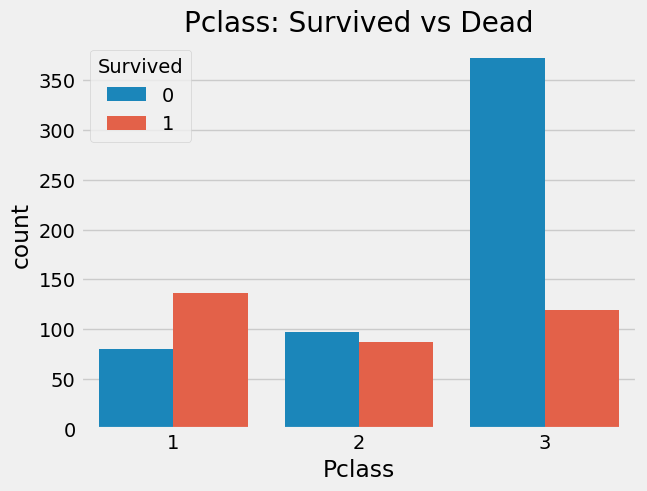

In [51]:
#illustrates the relationship between passenger class (Pclass) and survival status (Survived).
#x-axis (Pclass): Passenger ticket class:
#1 = 1st Class (Upper/Wealthiest)
#2 = 2nd Class (Middle)
#3 = 3rd Class (Lower/Economy)
#y-axis (count): Number of passengers.
#Colors (hue='Survived'):
#Blue Bar (0): Passengers who died.
#Red/Orange Bar (1): Passengers who survived.

sb.countplot(x='Pclass', hue='Survived', data=train_data)
plt.title('Pclass: Survived vs Dead')
plt.show()

In [52]:
#This code creates a cross-tabulation table (contingency table) that breaks down passenger counts by combining three features at once: Gender (Sex), Survival Status (Survived), and Passenger Class (Pclass).
pd.crosstab([train_data.Sex,train_data.Survived],train_data.Pclass,margins=True).style.background_gradient(cmap='summer_r')

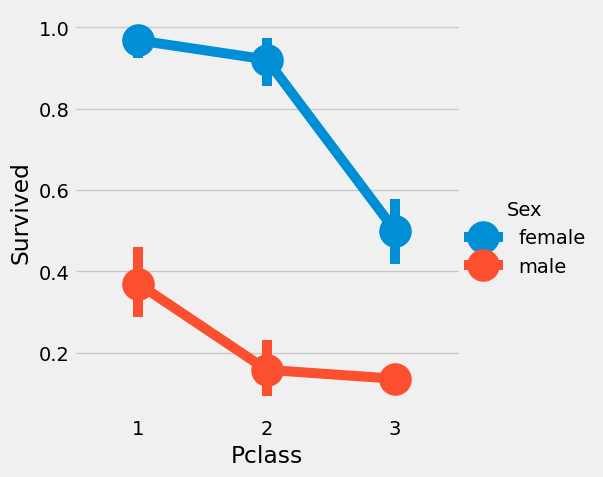

In [53]:
#This point plot visualizes the interaction between Passenger Class (Pclass) and Gender (Sex) in predicting survival probability (Survived).
sb.catplot(x='Pclass', y='Survived', hue='Sex', data=train_data, kind='point')
plt.show()

In [54]:
survived_df = train_data[train_data['Survived'] == 1]

print('Oldest person Survived was of:', survived_df['Age'].max())
print('Youngest person Survived was of:', survived_df['Age'].min())
print('Average person Survived was of:', survived_df['Age'].mean())

Oldest person Survived was of: 80.0
Youngest person Survived was of: 0.42
Average person Survived was of: 28.343689655172415


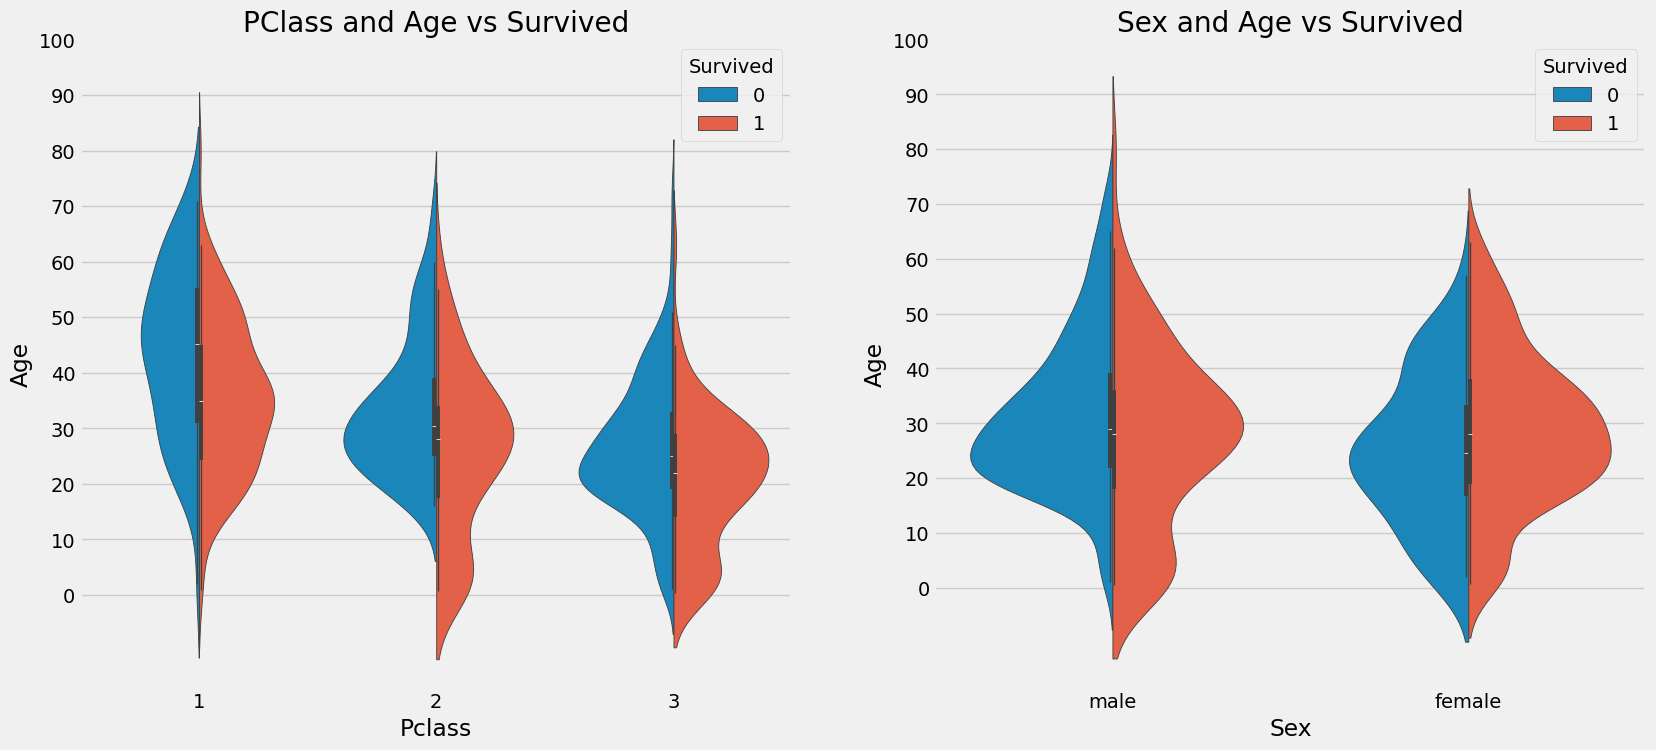

In [55]:
f, ax = plt.subplots(1, 2, figsize=(18, 8))

# Left plot: Pclass vs Age
sb.violinplot(x='Pclass', y='Age', hue='Survived', data=train_data, split=True, ax=ax[0])
ax[0].set_title('PClass and Age vs Survived')
ax[0].set_yticks(range(0, 110, 10))

# Right plot: Sex vs Age
sb.violinplot(x='Sex', y='Age', hue='Survived', data=train_data, split=True, ax=ax[1])
ax[1].set_title('Sex and Age vs Survived')
ax[1].set_yticks(range(0, 110, 10))

plt.show()

In [56]:
train_data['Initial']=0
for i in train_data:
    train_data['Initial']=train_data.Name.str.extract('([A-Za-z]+)\.') #extracting Name initials

In [57]:
pd.crosstab(train_data.Initial,train_data.Sex).T.style.background_gradient(cmap='summer_r')

Initial,Capt,Col,Countess,Don,Dr,Jonkheer,Lady,Major,Master,Miss,Mlle,Mme,Mr,Mrs,Ms,Rev,Sir
Sex,,,,,,,,,,,,,,,,,
female,0,0,1,0,1,0,1,0,0,182,2,1,0,125,1,0,0
male,1,2,0,1,6,1,0,2,40,0,0,0,517,0,0,6,1


In [60]:
train_data['Initial'] = train_data['Initial'].replace(
    ['Mlle', 'Mme', 'Ms', 'Dr', 'Major', 'Lady', 'Countess', 'Jonkheer', 'Col', 'Rev', 'Capt', 'Sir', 'Don'],
    ['Miss', 'Miss', 'Miss', 'Mr', 'Mr', 'Mrs', 'Mrs', 'Other', 'Other', 'Other', 'Mr', 'Mr', 'Mr']
)

In [62]:
train_data.groupby('Initial')['Age'].mean() #this table shows the Average (Mean) Age for each group:

Initial
Master     4.574167
Miss      21.860000
Mr        32.739609
Mrs       35.981818
Other     45.888889
Name: Age, dtype: float64

In [65]:
train_data.loc[(train_data.Age.isnull()) & (train_data.Initial=='Mr'),'Age']=33 #Finds all passengers whose age is missing (NaN) AND whose title is Mr, then assigns their age as 33 (rounded from $32.74$).
train_data.loc[(train_data.Age.isnull()) & (train_data.Initial=='Mrs'),'Age']=36 #Fills missing ages for Mrs with 36 (rounded from $35.98$).
train_data.loc[(train_data.Age.isnull()) & (train_data.Initial=='Master'),'Age']=5 #Fills missing ages for Master with 5 (rounded from $4.57$).
train_data.loc[(train_data.Age.isnull()) & (train_data.Initial=='Miss'),'Age']=22 #Fills missing ages for Miss with 22 (rounded from $21.86$).
train_data.loc[(train_data.Age.isnull()) & (train_data.Initial=='Other'),'Age']=46 #Fills missing ages for Other rare titles with 46 (rounded from $45.89$).

In [67]:
#This confirms that all missing age values have been successfully filled in the previous step. There are 0 missing values left in the Age column, and your dataset is now completely clean for that feature!
train_data.Age.isnull().any()

np.False_

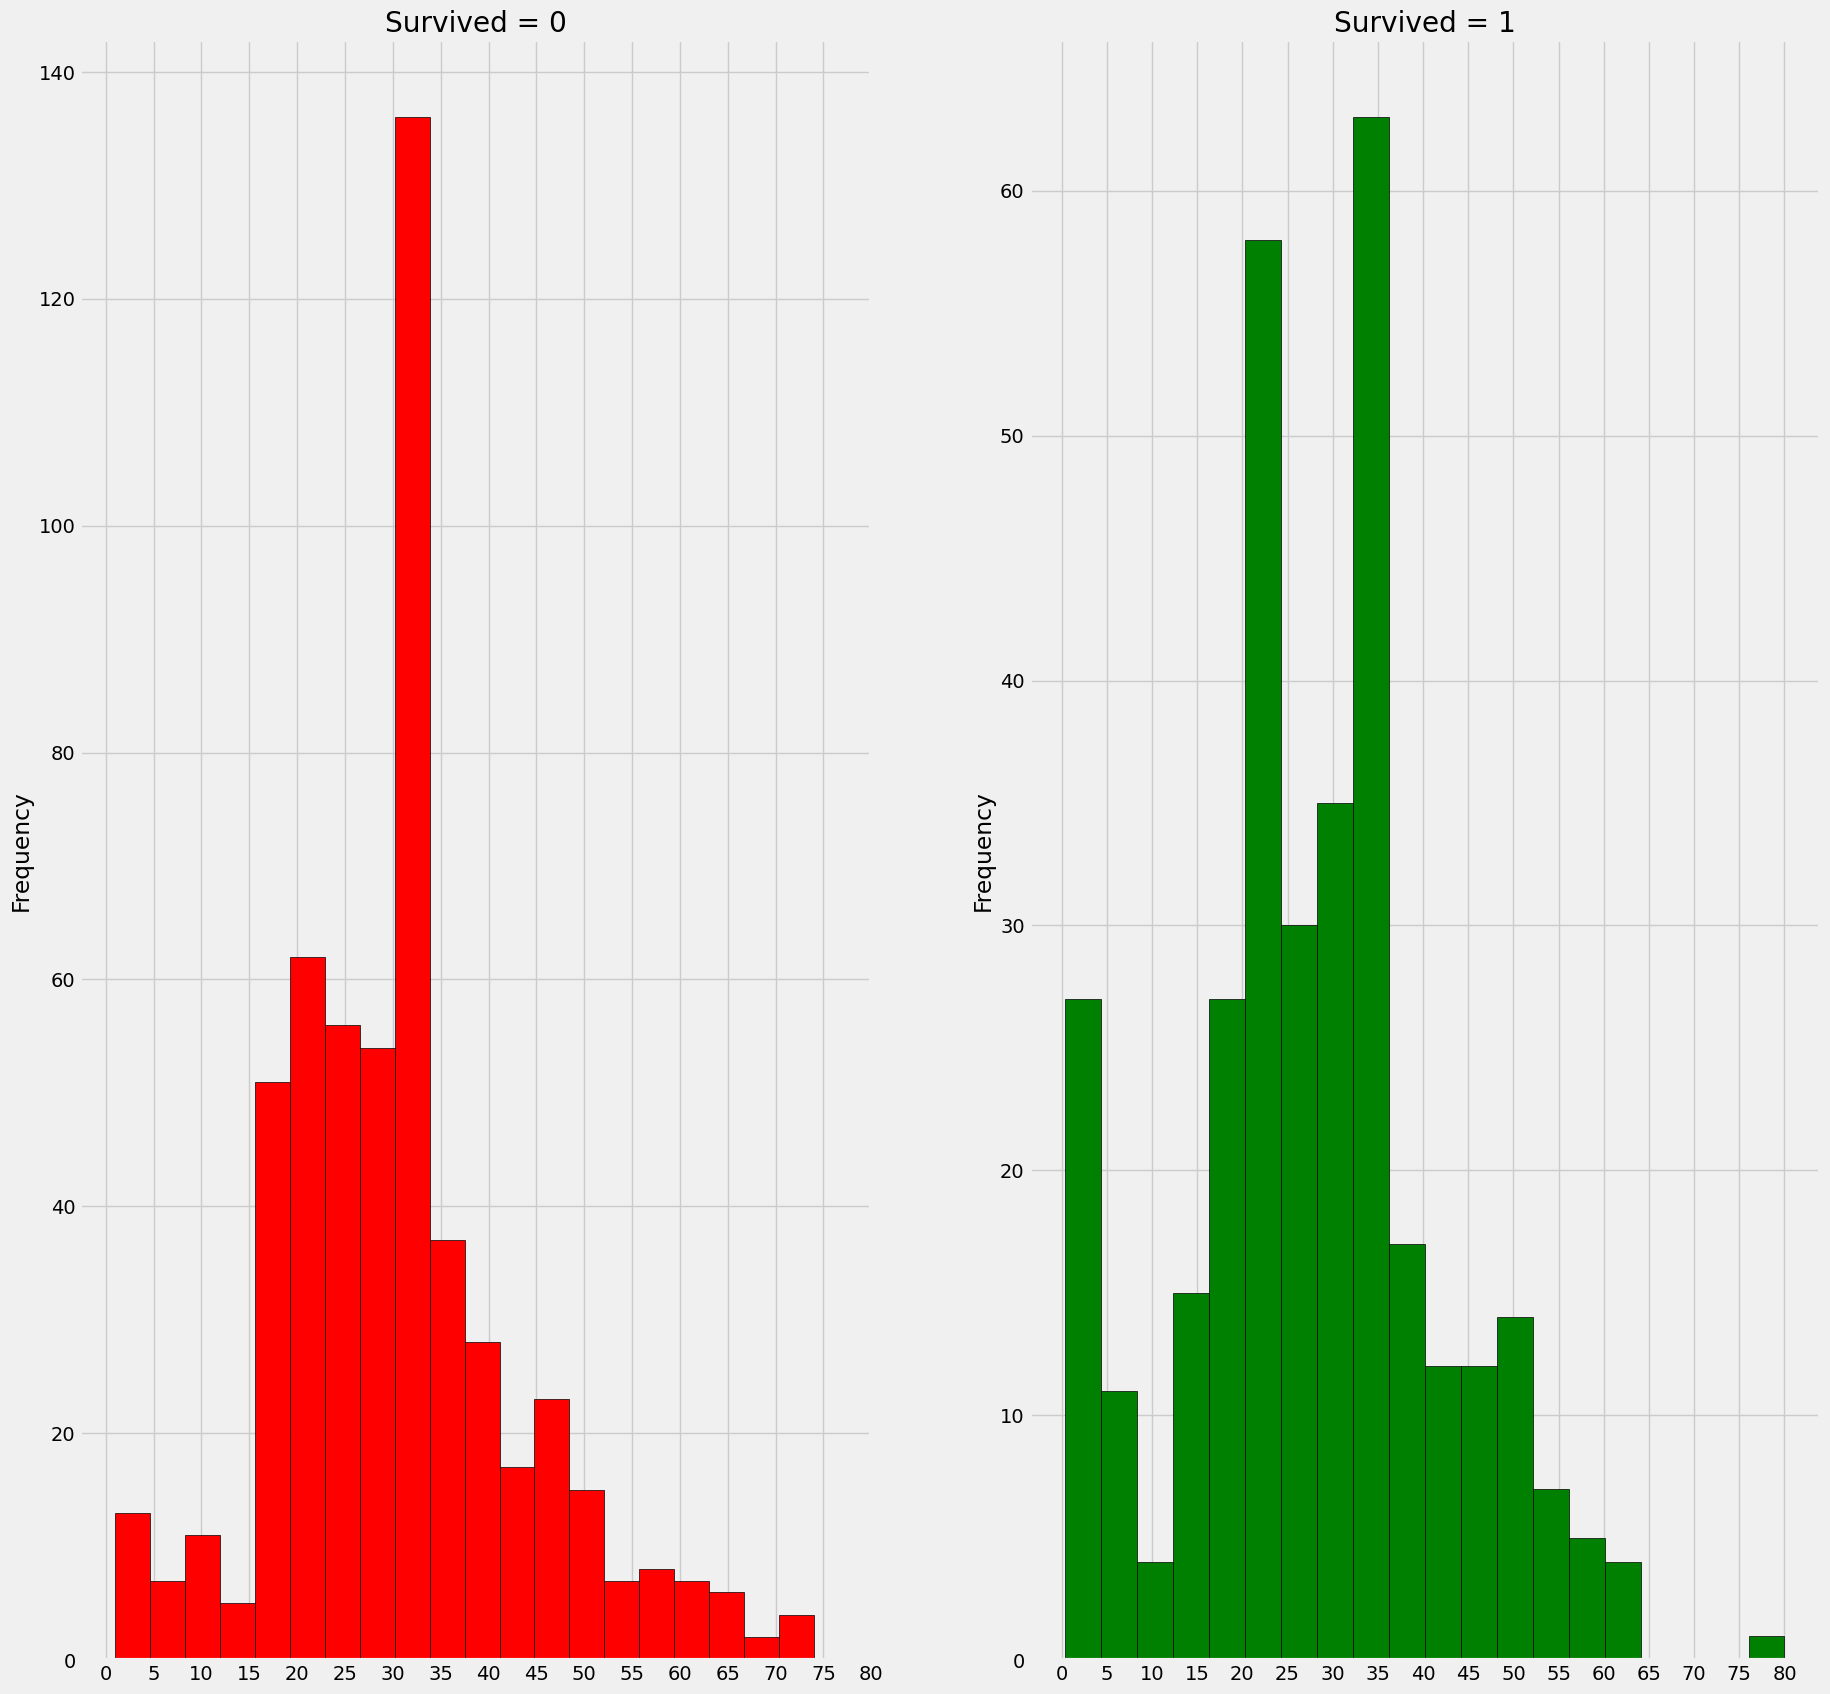

In [68]:
f,ax=plt.subplots(1,2,figsize=(20,20))
train_data[train_data['Survived']==0].Age.plot.hist(ax=ax[0],bins=20,edgecolor='black',color='red')
ax[0].set_title('Survived = 0')
x1=list(range(0,85,5))
ax[0].set_xticks(x1)
train_data[train_data['Survived']==1].Age.plot.hist(ax=ax[1],bins=20,edgecolor='black',color='green')
x2=list(range(0,85,5))
ax[1].set_xticks(x2)
ax[1].set_title('Survived = 1')
plt.show()

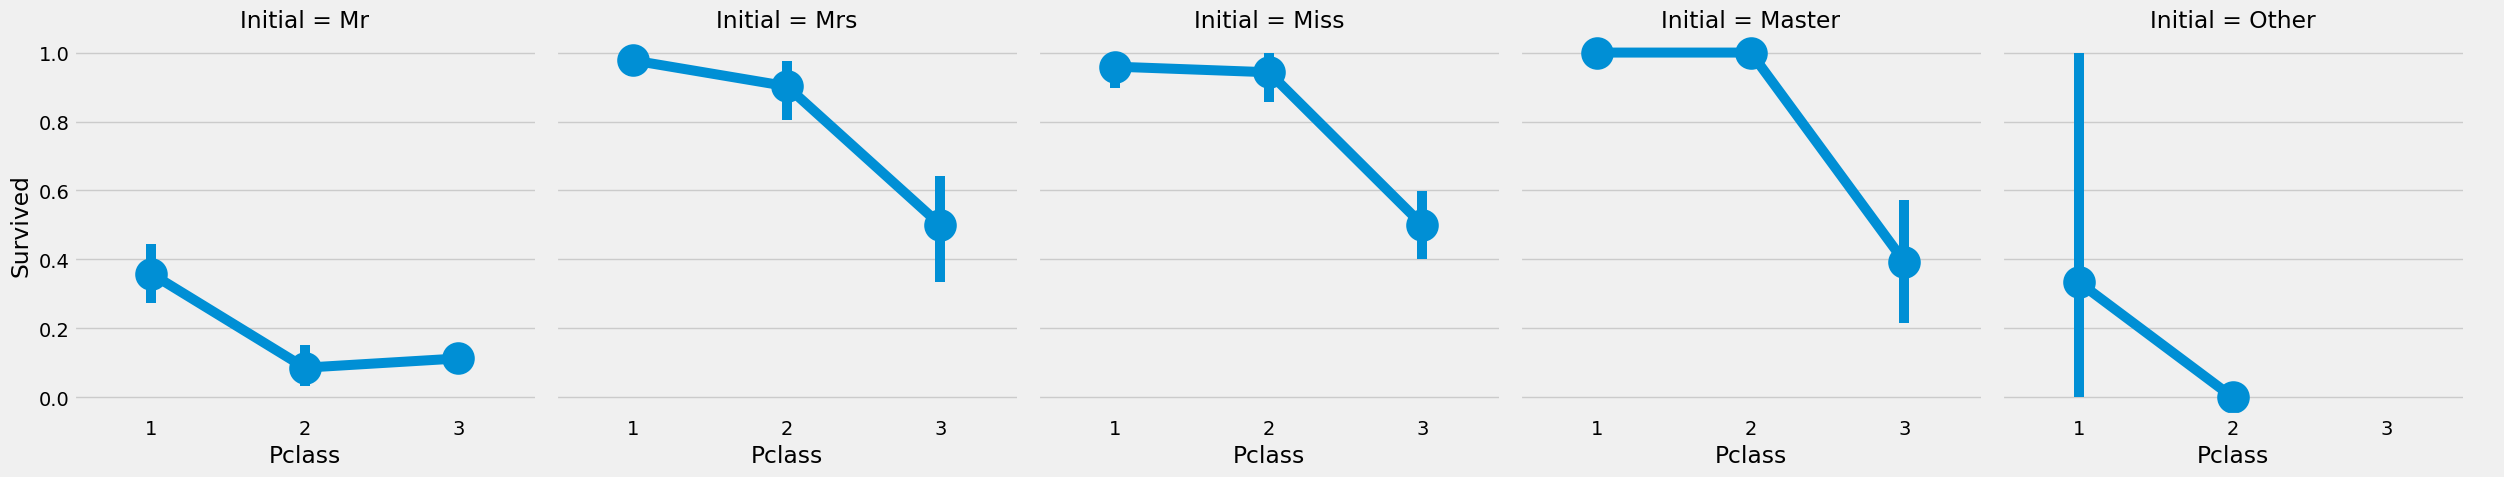

In [71]:
sb.catplot(x='Pclass', y='Survived', col='Initial', data=train_data, kind='point')
plt.show()

In [72]:
pd.crosstab([train_data.SibSp],train_data.Survived).style.background_gradient('summer_r')

Survived,0,1
SibSp,,
0,398,210
1,97,112
2,15,13
3,12,4
4,15,3
5,5,0
8,7,0


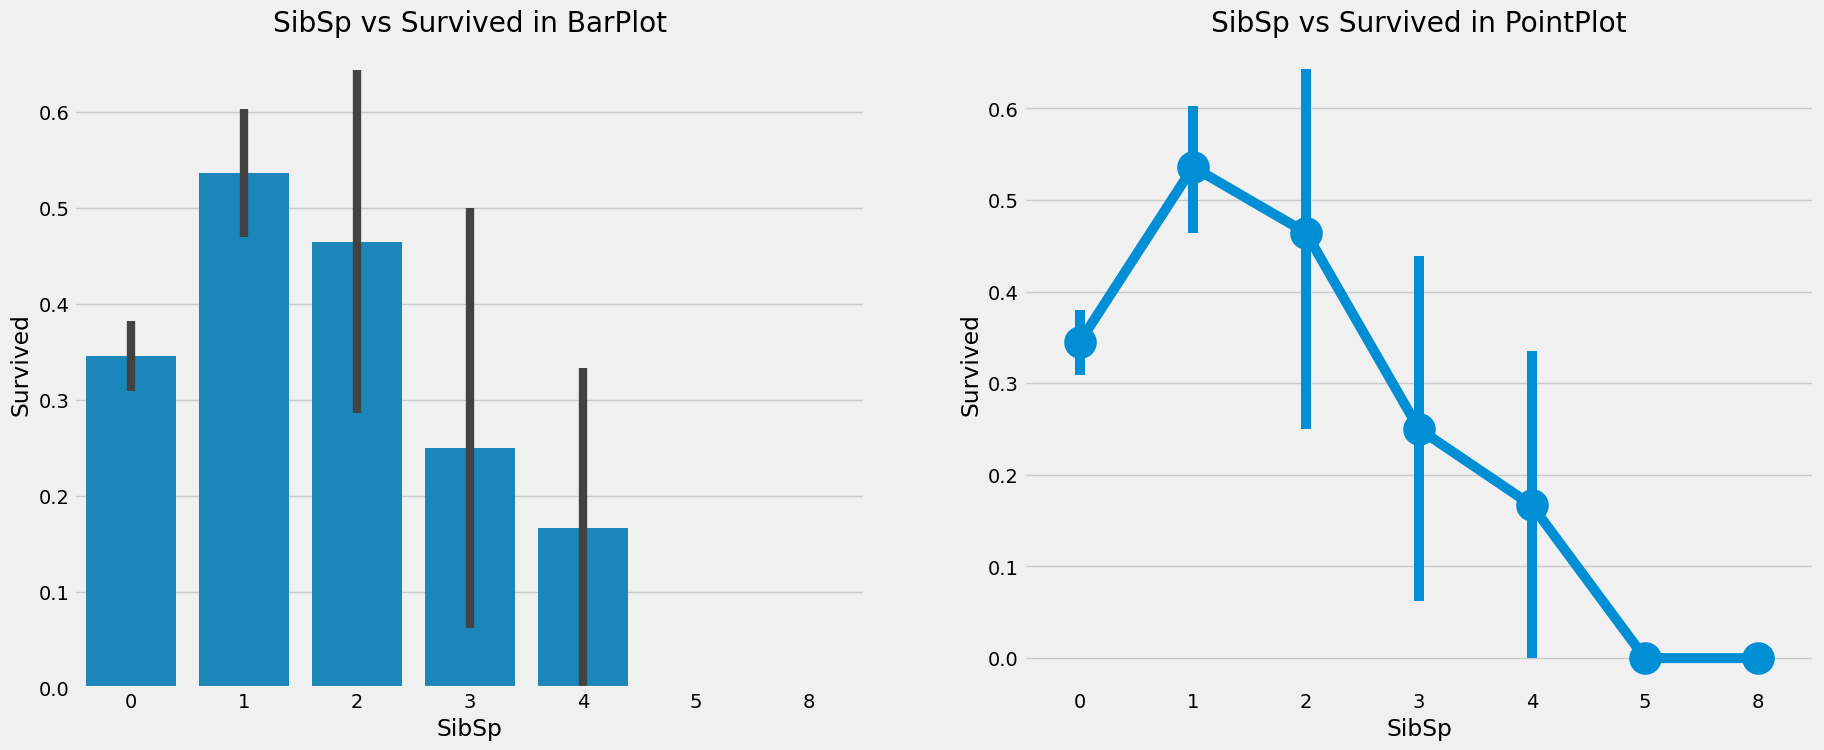

In [74]:
f, ax = plt.subplots(1, 2, figsize=(20, 8))

# Left plot: BarPlot
sb.barplot(x='SibSp', y='Survived', data=train_data, ax=ax[0])
ax[0].set_title('SibSp vs Survived in BarPlot')

# Right plot: PointPlot
sb.pointplot(x='SibSp', y='Survived', data=train_data, ax=ax[1])
ax[1].set_title('SibSp vs Survived in PointPlot')

plt.show()

In [75]:
pd.crosstab(train_data.SibSp,train_data.Pclass).style.background_gradient('summer_r')

Pclass,1,2,3
SibSp,,,
0,137,120,351
1,71,55,83
2,5,8,15
3,3,1,12
4,0,0,18
5,0,0,5
8,0,0,7
